# **OCULAR DISEASES DETECTION USING TRANSFER LEARNING APPROCHES**

## **BUSINESS CASE:  BASED ON THE GIVEN IMAGES WE NEED TO CLASSIFY THE  OCULAR DISEASES**

## **TASK: MULTICLASS CLASSIFICATION**

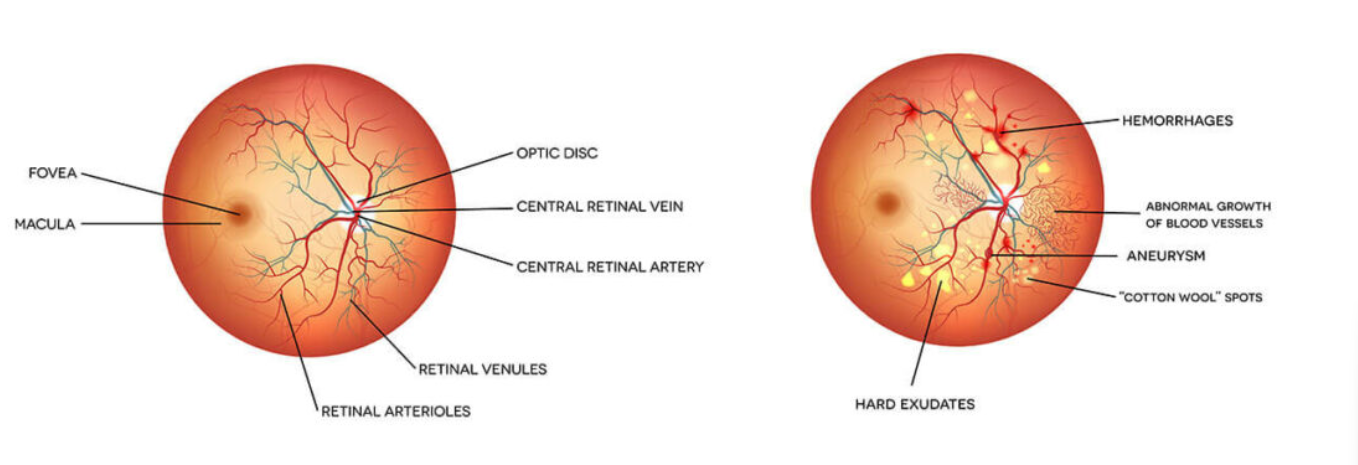

### Eye diseases are important causes of vision loss, and timely and correct diagnosis is essential for effective treatment and prevention of eye diseases. However, manual diagnosis by ophthalmologists may be under-typed and may be contested with limited specialist access.

### This project aims to develop a transfer learning-based AI system to detect and classify a wide range of ocular diseases from medical imaging data, helping to improve diagnostic accuracy, reduce healthcare costs, and provide timely interventions. Utilize different pre-trained deep learning models and embed interpretability techniques to allow explainable predictions to instigate trust and utilization in a clinical context.

## **DATA SUMMARY**

* Dataset contains total 6195 images divided into 4 classes

* 3981 images for training, 1562 images for validation, 652 images for testing.

* Normal: 1468 | Glaucoma: 1292 | Diabetic Retinopathy: 1946 | Cataract: 1489


## **DEVICE PROJECT INTO MULTIPLE STEPS**
* Image Processing using CLAHE (Contrast Limited Adaptive Histogram Equalization)
* Prepare training, validation and testing set and perfrom Data Augmentation
* Get all classes labels
* Compute the all class weights
* Visualise the training images
* Used DCNN, VGG19, VGG16 and Xception,InceptionV3 pre-trained model
* Model Compilation
* Model Training
* Model Evaluation
* Model Saving
* Prediction on test data using gradio space

## **PYTHON IMPLIMENTATION**

In [1]:
#Import Necessary Liabrary
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array,load_img
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Lambda, UpSampling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam, Adamax, SGD
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import gradio as gr
from lime import lime_image
from skimage.segmentation import mark_boundaries

# To supress warnings
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **APPLY CLAHE (CONTRAST LIMITED ADAPTIVE HISTOGRAM EQUALIZATION) PROCESSING TO TRAIN, VALIDATION AND TEST DATA AND STORE PROCESS IMAGES INTO DIFFERENT FOLDER**

In [ ]:
data_dir = r"C:\Users\hp\Downloads\Ocular\data"

train_dir = os.path.join(data_dir, 'train')
valid_dir = os.path.join(data_dir,'valid')
test_dir = os.path.join(data_dir, 'test')

In [ ]:
def clahe_gray(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)   # Convert image into lab color space
    l, a, b = cv2.split(lab)                     # split the lab image into its channel
    clahe = cv2.createCLAHE(clipLimit=3, tileGridSize=(8,8))  # Create clahe object
    cl = clahe.apply(l)      # apply clahe to the l channel image
    limg = cv2.merge((cl,a,b))           # Merge clahe enhnaced l channel
    final_image = cv2.cvtColor(limg,cv2.COLOR_LAB2BGR)  # Convert back to bgr color space
    return final_image

In [ ]:
def process_images_in_directory(directory):
    for class_dir in os.listdir(directory):
        class_path = os.path.join(directory, class_dir)
        if os.path.isdir(class_path):
            # Process JPG images
            for img_path in glob(os.path.join(class_path, '*.jpg')):
                process_and_save_image(img_path)

            # Process JPEG images
            for img_path in glob(os.path.join(class_path, '*.jpeg')):
                process_and_save_image(img_path)

            # Process PNG images
            for img_path in glob(os.path.join(class_path, '*.png')):
                process_and_save_image(img_path)

def process_and_save_image(img_path):
    image = cv2.imread(img_path)  # Read image
    if image is not None:
        processed_image = clahe_gray(image)  # Apply CLAHE
        output_path = img_path.replace('data', 'clahe_data')
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        cv2.imwrite(output_path, processed_image)
        print(f"Processed and saved: {output_path}")


In [ ]:
process_images_in_directory(train_dir)
process_images_in_directory(valid_dir)
process_images_in_directory(test_dir)

Processed and saved: C:\Users\hp\Downloads\Ocular\clahe_data\train\Cataract\0_left_jpg.rf.02630da82c0d3e0cfe1a8e2f8ed5110f.jpg

Processed and saved: C:\Users\hp\Downloads\Ocular\clahe_data\train\Cataract\0_left_jpg.rf.d5cbdb475e82ed46c40bda65adc0f182.jpg

Processed and saved: C:\Users\hp\Downloads\Ocular\clahe_data\train\Cataract\103_left_jpg.rf.06fc44fe0d796407ef62503d4109cc47.jpg

Processed and saved: C:\Users\hp\Downloads\Ocular\clahe_data\train\Cataract\103_left_jpg.rf.288cc1a4fd0849a8cca5e53735739bc6.jpg

Processed and saved: C:\Users\hp\Downloads\Ocular\clahe_data\train\Cataract\103_left_jpg.rf.d0a6a032ea8f65ace4ddb2fb341774af.jpg

Processed and saved: C:\Users\hp\Downloads\Ocular\clahe_data\train\Cataract\1062_right_jpg.rf.0c3296f6fffe41d665730bfe74048ebc.jpg

Processed and saved: C:\Users\hp\Downloads\Ocular\clahe_data\train\Cataract\1062_right_jpg.rf.7a4cd40163ab31b63b126af9ef305d95.jpg

Processed and saved: C:\Users\hp\Downloads\Ocular\clahe_data\train\Cataract\1062_right_jpg

## **PREPARE TRAINING, VALIDATION AND TESTING DATA AND PERFORM DATA AGUMENTATION**

In [3]:
clahe_train_dir = r"C:\Users\hp\Downloads\ODD NEW\clahe_data\train"
clahe_val_dir   = r"C:\Users\hp\Downloads\ODD NEW\clahe_data\valid"
clahe_test_dir  = r"C:\Users\hp\Downloads\ODD NEW\clahe_data\test"

In [4]:
train_datagen = ImageDataGenerator(rescale=(1.0 / 255),
                                   rotation_range=20,
                                   featurewise_center=True,
                                   featurewise_std_normalization=True,
                                   fill_mode='nearest',
                                   zoom_range=0.2,
                                   horizontal_flip=True)


val_datagen = ImageDataGenerator(rescale=(1. / 255))

test_datagen = ImageDataGenerator(rescale=(1. / 255))

In [5]:
train_set = train_datagen.flow_from_directory(clahe_train_dir,
                                              target_size=(256,256),
                                              batch_size=64,
                                              color_mode='rgb',
                                              class_mode='categorical')

val_set = val_datagen.flow_from_directory(clahe_val_dir,
                                          target_size=(256,256),
                                          batch_size=64,
                                          color_mode='rgb',
                                          class_mode='categorical')

test_set = test_datagen.flow_from_directory(clahe_test_dir,
                                            target_size=(256,256),
                                            batch_size=64,
                                            color_mode='rgb',
                                            class_mode='categorical')

Found 3981 images belonging to 4 classes.
Found 1562 images belonging to 4 classes.
Found 652 images belonging to 4 classes.


In [6]:
# Get classes indices
train_set.class_indices

{'Cataract': 0, 'Diabetic_retinopathy': 1, 'Glaucoma': 2, 'Normal': 3}

### **SEPARATE LABEL FROM TEST SET**

In [7]:
X_test, y_test = next(test_set)

In [16]:
print(X_test.shape)

(64, 256, 256, 3)


In [18]:
print(y_test)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


## **GET CLASS WEIGHTS**

In [ ]:
# Get the class labels and their frequencies
from sklearn.utils.class_weight import compute_class_weight

class_labels = train_set.classes
unique_classes = np.unique(class_labels)

In [ ]:
print("Class Labels: ", class_labels)
print("Unique Classes:", unique_classes)

Class Labels:  [0 0 0 ... 3 3 3]
Unique Classes: [0 1 2 3]


In [ ]:
# Compute the class weights
class_weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=class_labels)

# Create dict of class weights
class_weight_dict = dict(zip(unique_classes, class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 1.0554082714740192, 1: 0.7799764890282131, 2: 1.2440625, 3: 1.0345634095634095}


## **VISUALISE THE TRAINING IMAGES**

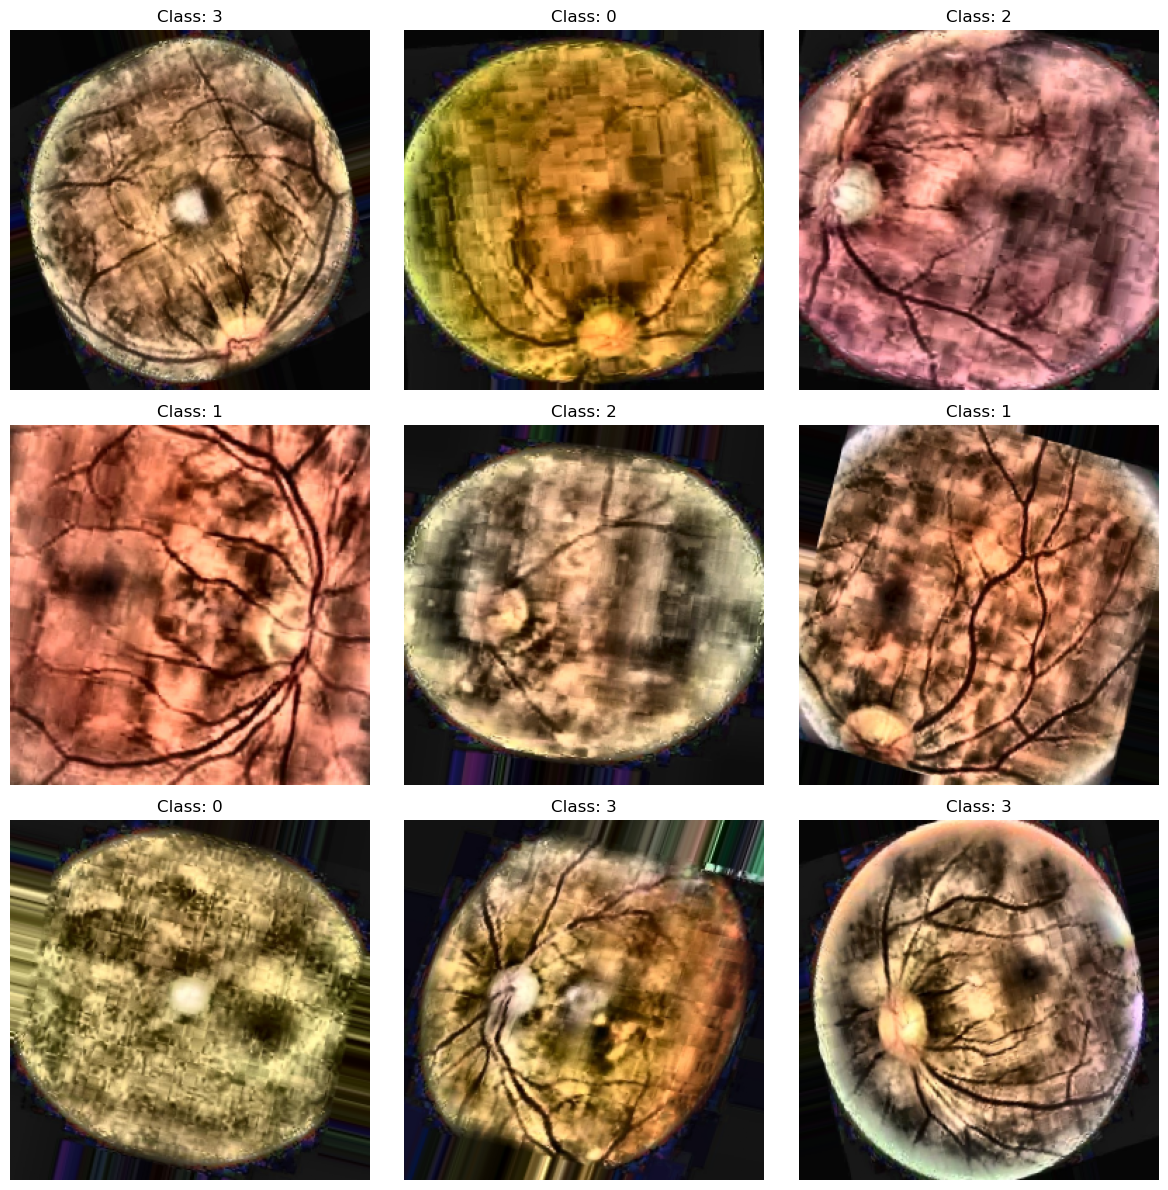

In [ ]:
# Seprate the images and labels from training set
img, label = next(train_set)

plt.figure(figsize=(12, 12))
for i in range(9):  # Plotting 9 images
    plt.subplot(3, 3, i + 1)
    plt.imshow(img[i])
    plt.title(f'Class: {label[i].argmax()}')  # Assuming labels are one-hot encoded
    plt.axis('off')
plt.tight_layout()
plt.show()

### **DEEP CONVOLUTIONAL NEURAL NETWORK (DCNN)**

In [17]:
dcnn_model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Flatten layer
    Flatten(),

    # Fully Connected layers
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 classes
])

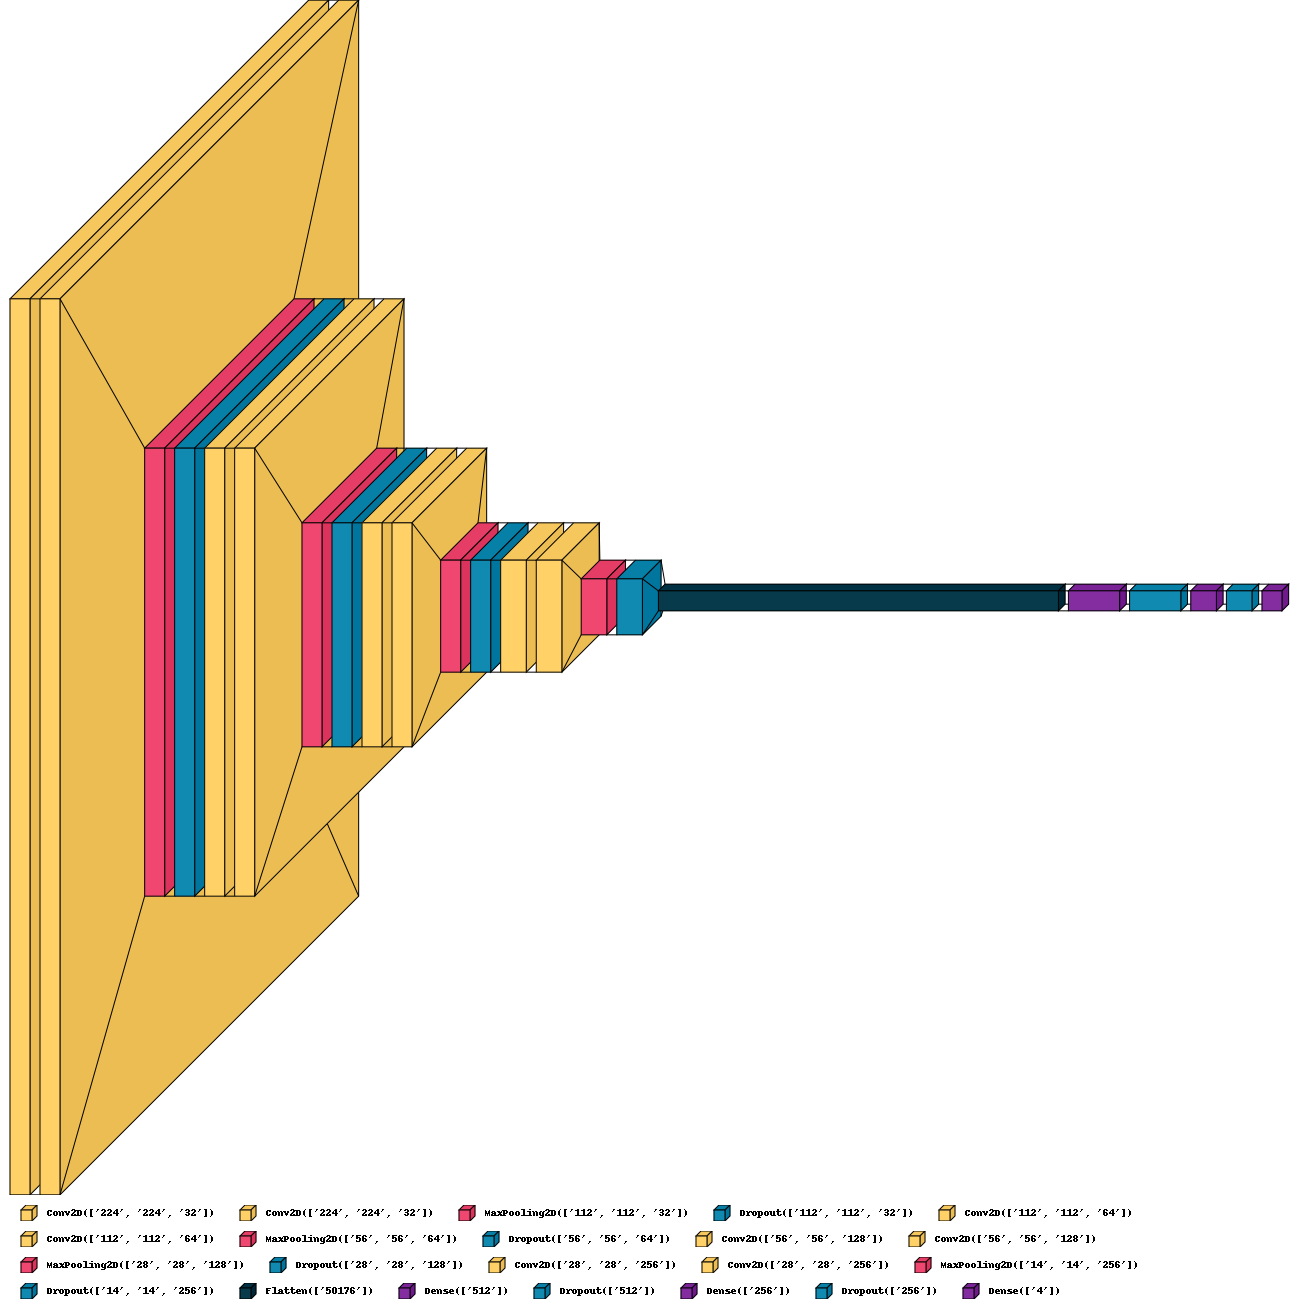

In [8]:
import visualkeras
visualkeras.layered_view(dcnn_model,legend=True,show_dimension=True)

In [ ]:
# summary of dcnn model
dcnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,995,236 (102.98 MB)

 Trainable params: 26,995,236 (102.98 MB)

 Non-trainable params: 0 (0.00 B)

### **COMPILE AND TRAIN MODEL**

In [ ]:
# Compile the model with Adam optimizer
optimizer = Adam(learning_rate=0.0001, clipnorm=1.0)
dcnn_model.compile(optimizer=optimizer,
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

In [ ]:
# Use ModelCheckPoint and Early stopping to avoid overfitting problem
dcnn_early_stop = EarlyStopping(monitor='val_loss',
                                patience=15,
                                verbose=1)

dcnn_modelCheckpoint = ModelCheckpoint(filepath='new_dcnn_model.keras',
                                       monitor='val_loss',
                                       verbose=True,
                                       save_best_only=True)

# fit model for training
dcnn_history = dcnn_model.fit(train_set,
                              epochs=200,
                              validation_data=val_set,
                              class_weight=class_weight_dict,
                              callbacks=[dcnn_early_stop, dcnn_modelCheckpoint])

Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.4356 - loss: 1.2675
Epoch 1: val_loss improved from inf to 1.18192, saving model to new_dcnn_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 969ms/step - accuracy: 0.4362 - loss: 1.2664 - val_accuracy: 0.4968 - val_loss: 1.1819
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.5108 - loss: 1.1486
Epoch 2: val_loss improved from 1.18192 to 1.12525, saving model to new_dcnn_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 961ms/step - accuracy: 0.5109 - loss: 1.1483 - val_accuracy: 0.5218 - val_loss: 1.1252
Epoch 3/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.5517 - loss: 1.0690
Epoch 3: val_loss did not improve from 1.12525
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 936ms/step - accuracy: 0.5518 - loss: 1.0688 - val_accuracy: 0.4654 - val_loss: 1.2088
Epoch 4/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.5787 - loss: 1.0321
Epoch 4: val_loss improved from 1.12525 to 1.01722, saving model to new_dcnn_

### **PLOT DCNN MODEL TRAIN ACCURACY & LOSS AS WELL AS VALIDATION ACCURACY LOSS**

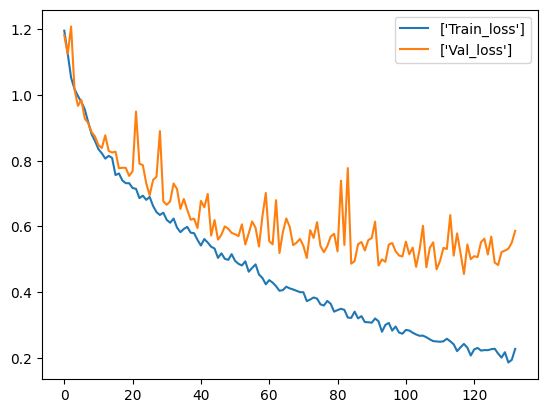

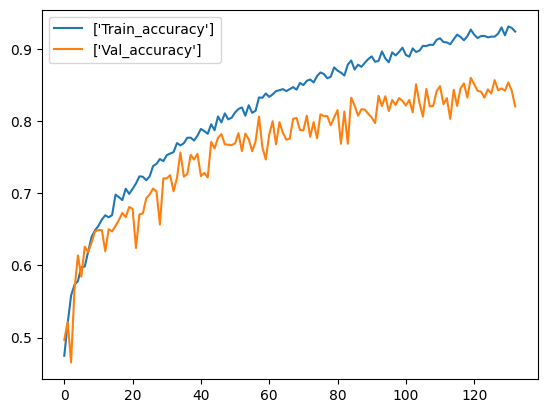

In [ ]:
plt.plot(dcnn_history.history['loss'], label=['Train_loss'])
plt.plot(dcnn_history.history['val_loss'], label=['Val_loss'])
plt.legend()
plt.show()
plt.savefig('DCNN_train_val_loss')

plt.plot(dcnn_history.history['accuracy'], label=['Train_accuracy'])
plt.plot(dcnn_history.history['val_accuracy'], label=['Val_accuracy'])
plt.legend()
plt.savefig('DCNN_train_val_accuracy')
plt.show()


In [ ]:
train_loss, train_accuracy = dcnn_model.evaluate(train_set)
test_loss, test_accuracy = dcnn_model.evaluate(test_set)
print(f"Train Loss:{train_loss:.4f}")
print(f"Train Accuracy:{train_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 56s 881ms/step - accuracy: 0.9578 - loss: 0.1148
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - accuracy: 0.8854 - loss: 0.4724
Train Loss:0.1098
Train Accuracy:0.9608
Test Loss: 0.5183
Test Accuracy: 0.8696


* DCNN model training accuray is 96% and testing accuracy is 86%.Model is slightly overfit

### **PREDICTION ON TEST DATA**

In [ ]:
# Predict labels for the test set
dcnn_ypred = dcnn_model.predict(X_test)

# Get class labels from predictions
y_pred_labels = np.argmax(dcnn_ypred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,f1_score,accuracy_score, recall_score

dcnn_confusion_matrix = confusion_matrix(y_test_labels, y_pred_labels)
print("Confusion Matrix:\n", dcnn_confusion_matrix)

Confusion Matrix:
 [[16  2  3  0]
 [ 0 14  0  1]
 [ 0  1  9  2]
 [ 1  1  2 12]]


In [ ]:
# F1 Score
dcnn_f1score = f1_score(y_test_labels, y_pred_labels,average='weighted')
print("F1 Score:", dcnn_f1score*100)

# Classification report
dcnn_report = classification_report(y_test_labels, y_pred_labels)
print("Classification Report:\n", dcnn_report)

F1 Score: 79.8535505241787
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.76      0.84        21
           1       0.78      0.93      0.85        15
           2       0.64      0.75      0.69        12
           3       0.80      0.75      0.77        16

    accuracy                           0.80        64
   macro avg       0.79      0.80      0.79        64
weighted avg       0.81      0.80      0.80        64



### INTEGRATE DCNN MODEL WITH XAI
#### 1. LIME

In [15]:
!pip install lime

     ---------------------------------------- 0.0/275.7 kB ? eta -:--:--
     - -------------------------------------- 10.2/275.7 kB ? eta -:--:--
     ----- ------------------------------- 41.0/275.7 kB 487.6 kB/s eta 0:00:01
     ------------------------------------ - 266.2/275.7 kB 2.0 MB/s eta 0:00:01
     -------------------------------------- 275.7/275.7 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283846 sha256=f552b24f9e208902f744e8ce881ac4f1b4d38334885908acfd07738e50f8dbc5
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\85\fa\a3\9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [2]:
# Load DCNN Model 
model = load_model("new_dcnn_model.keras")

# Create function to enhance image using CLAHE
def image_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)  
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final

# Create function to preprocess image
def preprocessing(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = img.astype(np.uint8)  # Ensure the image is in uint8 format
    img = image_clahe(img)
    img = img.astype(np.float32) / 255.0  # Convert to float32 and normalize
    img_array = np.expand_dims(img, axis=0)
    return img_array

img_path = r"C:\Users\hp\Downloads\ODD NEW\data\test\Diabetic_retinopathy\11364_right_jpeg_jpg.rf.816d60135edbda2c1974544f96132f4f.jpg"
process_image = preprocessing(img_path)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

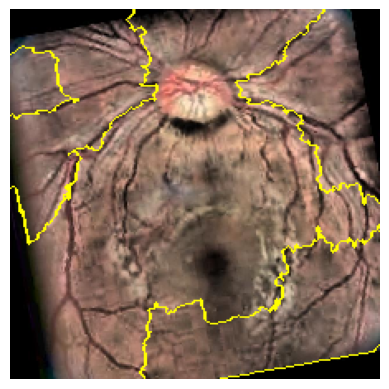

In [3]:
img = image.load_img(img_path, target_size=(224, 224)) # Load the original image with target size
img = image.img_to_array(img).astype(np.uint8)

explainer = lime_image.LimeImageExplainer() # Initialize the LIME explainer

# Define a prediction function
def predict(images):
    images = np.array([image_clahe(img) for img in images])
    images = images.astype(np.float32) / 255.0  # Normalize
    return model.predict(images)

# Generate explanation
explanation = explainer.explain_instance(img, predict, top_labels=1, hide_color=0, num_samples=1000)

# Get the image and mask for the top class
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=10, hide_rest=False)

# Display the explanation
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis('off')
plt.show()


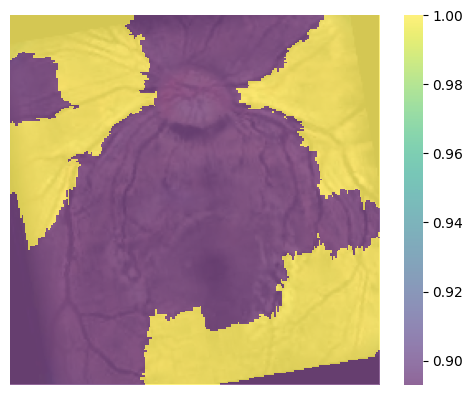

In [4]:
top_label = explanation.top_labels[0] # LIME explanation for the top class

local_explanation = dict(explanation.local_exp[top_label]) # Create a dictionary for the local explanations

heatmap = np.zeros(mask.shape) # Initialize the heatmap with zeros

# Map the superpixel indices to their importance values
for i in range(mask.shape[0]):
    for j in range(mask.shape[1]):
        if mask[i, j] in local_explanation:
            heatmap[i, j] = local_explanation[mask[i, j]]

heatmap /= np.max(heatmap) # Normalize the heatmap

# Plot the heatmap over the original image
fig, ax = plt.subplots()
sns.heatmap(heatmap, cmap='viridis', alpha=0.6, ax=ax, zorder=2, cbar=True)
ax.imshow(img / 255.0, zorder=1, alpha=0.4) # plot orginal image
ax.axis('off')
plt.show()

#### 2.Occlusion Sensitivity

In [23]:
# Load DCNN model
model = load_model("new_dcnn_model.keras")

# Apply CLAHE to the image
def image_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)  
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final

# Load and preprocess the image
img_path = r"C:\Users\hp\Downloads\ODD NEW\data\test\Diabetic_retinopathy\11364_right_jpeg_jpg.rf.816d60135edbda2c1974544f96132f4f.jpg"
img = image.load_img(img_path, target_size=(224, 224))
img = image.img_to_array(img).astype(np.uint8)
img_clahe = image_clahe(img)
img_clahe = img_clahe.astype(np.float32) / 255.0
img_array = np.expand_dims(img_clahe, axis=0)

In [ ]:
def occlusion_sensitivity(model, img, occlusion_size=15, stride=5):
    input_shape = img.shape[1:3]
    occlusion_heatmap = np.zeros(input_shape)

    for y in range(0, input_shape[0], stride):
        for x in range(0, input_shape[1], stride):
            occluded_img = img.copy()
            occluded_img[:, y:y+occlusion_size, x:x+occlusion_size, :] = 0
            preds = model.predict(occluded_img)
            occlusion_heatmap[y:y+occlusion_size, x:x+occlusion_size] = preds[0, tf.argmax(preds[0])]
    
    return occlusion_heatmap

occlusion_heatmap = occlusion_sensitivity(model, img_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/

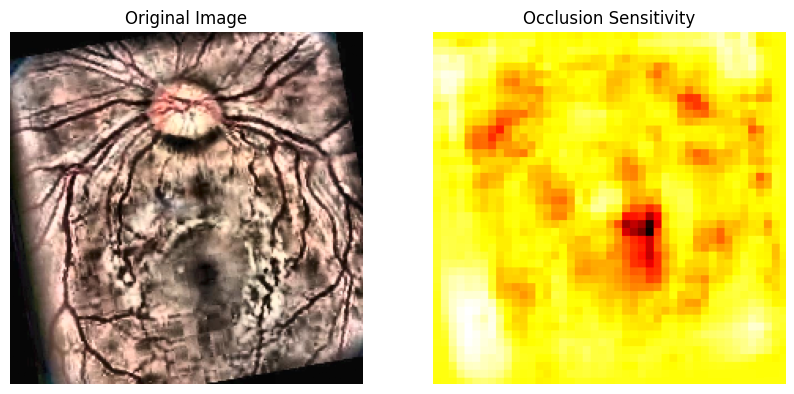

In [28]:
def visualize_occlusion_sensitivity(img, occlusion_heatmap):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(np.squeeze(img))
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title('Occlusion Sensitivity')
    plt.imshow(occlusion_heatmap, cmap='hot')
    plt.axis('off')
    
    plt.show()

visualize_occlusion_sensitivity(np.squeeze(img_array), occlusion_heatmap)


## VGG19 MODEL

In [9]:
# Define image size
image_shape = [256,256]

# Import Vgg19 library and add preprocessing layer in front og vgg
vgg19 = VGG19(input_shape=image_shape + [3], weights='imagenet', include_top=False)

80134624/80134624 [==============================] - 1s 0us/step


In [10]:
# Dont train the existing weights
for layer in vgg19.layers:
    layer.trainable = False

In [11]:
x = Flatten()(vgg19.output)
x = Dropout(0.5)(x)
prediction = Dense(4, activation='softmax')(x) # Add the output layer
vgg19_model = Model(inputs=vgg19.input, outputs=prediction) # Create the final model

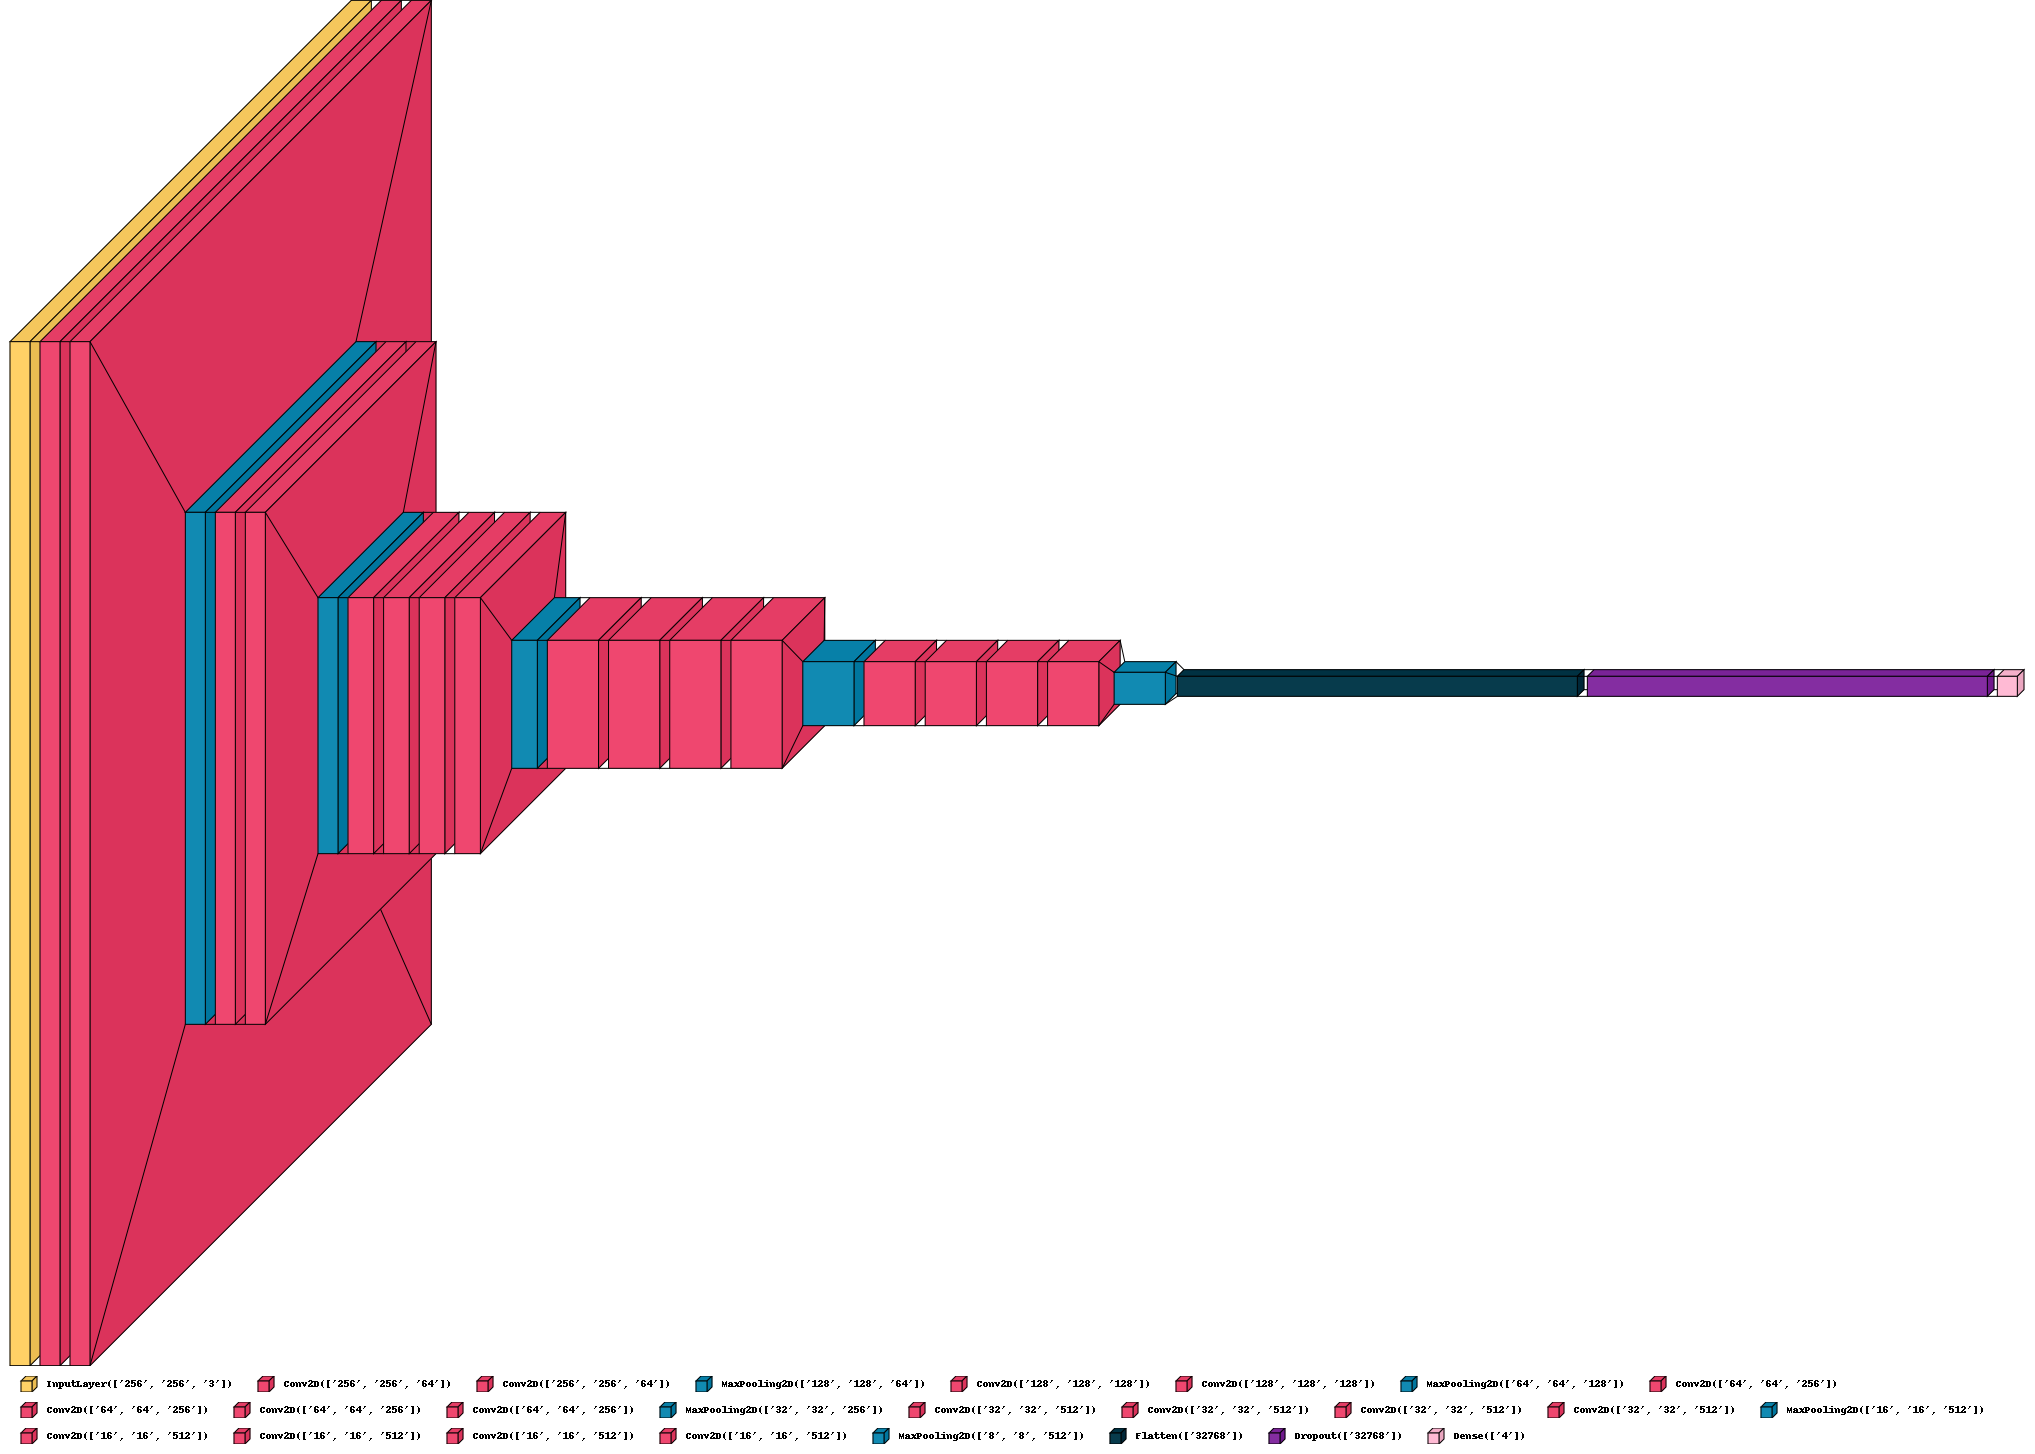

In [12]:
# Visualise the model
import visualkeras
visualkeras.layered_view(vgg19_model, legend=True,show_dimension=True)

In [ ]:
# Summary of VGG19 Model
vgg19_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │       131,07

 Total params: 20,155,460 (76.89 MB)

 Trainable params: 20,155,460 (76.89 MB)

 Non-trainable params: 0 (0.00 B)

### **COMIPLE AND TRAIN MODEL**

In [ ]:
# Compile the model with Adam optimizer
optimizer = Adam(learning_rate=0.0001)

# Compile the model with Adam optimizerfrom
vgg19_model.compile(optimizer= optimizer,
                    loss='categorical_crossentropy',  # Use crossentropy because we have only four classes
                    metrics=['accuracy'])

In [ ]:
# Add ReduceLRnPlateau callback to reduce the learning rate
vgg19_reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                    factor=0.5,
                                    patience=2,
                                    verbose=1,
                                    min_lr=0.00001)

# Add EarlyStopping
vgg19_early_stop = EarlyStopping(monitor='val_loss',
                                 patience=10,
                                 verbose=1)

# To save the best model
vgg19_checkpoint = ModelCheckpoint(filepath= 'NEW_VGG19_model.keras',verbose=1, save_best_only=True)

# train model on 100 epoch
vgg19_history = vgg19_model.fit(train_set,
                                epochs=100,
                                validation_data=val_set,
                                class_weight=class_weight_dict,
                                callbacks=[vgg19_reduce_lr,vgg19_early_stop,vgg19_checkpoint])

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6124 - loss: 0.9961
Epoch 1: val_loss improved from inf to 0.56599, saving model to NEW_VGG19_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.6138 - loss: 0.9923 - val_accuracy: 0.7721 - val_loss: 0.5660 - learning_rate: 1.0000e-04
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8223 - loss: 0.4696
Epoch 2: val_loss improved from 0.56599 to 0.47363, saving model to NEW_VGG19_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8223 - loss: 0.4695 - val_accuracy: 0.8399 - val_loss: 0.4736 - learning_rate: 1.0000e-04
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8414 - loss: 0.4320
Epoch 3: val_loss improved from 0.47363 to 0.41981, saving model to NEW_VGG19_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.8417 - loss: 0.4313 - val_accuracy: 0.8713 - val_loss: 0.4198 - learning_rate: 1.0000e-04
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - a

### **PLOTTING TRAINING & VALIDATION ACCURACY AS WELL AS LOSS & VALIDATION LOSS**

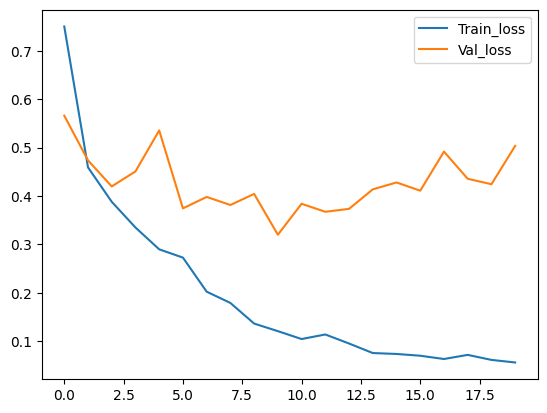

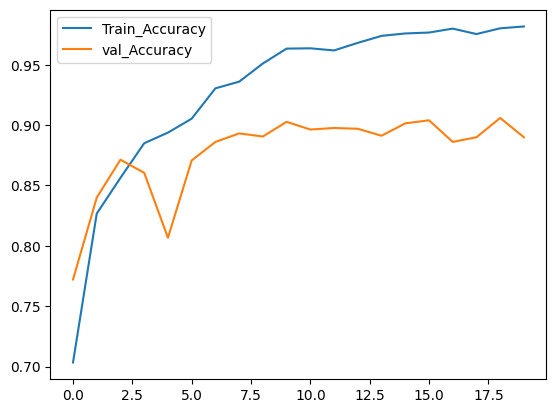

<Figure size 640x480 with 0 Axes>

In [ ]:
# Training loss and validation loss
plt.plot(vgg19_history.history['loss'], label='Train_loss')
plt.plot(vgg19_history.history['val_loss'], label='Val_loss')
plt.legend()
plt.show()
plt.savefig('vgg19Loss_valLoss')


# Training accuracy and validation accuracy
plt.plot(vgg19_history.history['accuracy'], label='Train_Accuracy')
plt.plot(vgg19_history.history['val_accuracy'], label='val_Accuracy')
plt.legend()
plt.show()
plt.savefig('vgg19Accuracy_ValAccuracy')

### **MODEL EVALUATION**

In [ ]:
train_result = vgg19_model.evaluate(train_set)
print("VGG19 Train Accuracy & Loss:",train_result)

test_result = vgg19_model.evaluate(test_set)
print("VGG19 Testing Accuracy & Loss",test_result)

63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9850 - loss: 0.0543
VGG19 Train Accuracy & Loss: [0.0536762997508049, 0.983421266078949]
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 0.9129 - loss: 0.3696
VGG19 Testing Accuracy & Loss [0.592086672782898, 0.9095091819763184]


* VGG19 Model perfrom well on training data with 98% training accuracy with 0.05 loss and the testing accuracy is 91% with 0.59%. Testing accuracy is slightly low, but we can consider these model. beacuse of complexity of data.

### **PREDICTION ON TEST DATA**

In [ ]:
# Predict labels for the test set
vgg19_ypred = vgg19_model.predict(X_test)

# Get class labels from predictions
y_pred_labels = np.argmax(vgg19_ypred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,f1_score,accuracy_score, recall_score

vgg19_confusion_matrix = confusion_matrix(y_test_labels, y_pred_labels)
print("Confusion Matrix:\n", vgg19_confusion_matrix)

Confusion Matrix:
 [[11  0  0  1]
 [ 0 24  0  0]
 [ 0  1 11  3]
 [ 0  0  0 13]]


In [ ]:
# check f1 score
vgg19_f1score = f1_score(y_test_labels, y_pred_labels, average='weighted')
print("F1 Score",vgg19_f1score*100)

vgg19_classification_report = classification_report(y_test_labels, y_pred_labels)
print("Classification Report:\n", vgg19_classification_report)

F1 Score 92.10537392214411
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.96      1.00      0.98        24
           2       1.00      0.73      0.85        15
           3       0.76      1.00      0.87        13

    accuracy                           0.92        64
   macro avg       0.93      0.91      0.91        64
weighted avg       0.94      0.92      0.92        64



* F1 Score of VGG19 Model is 92.10%.

## VGG16 MODEL

In [13]:
from tensorflow.keras.regularizers import l2

# Load the pre-trained VGG16 model without the top layers
vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Freeze the base model layers
for layer in vgg16.layers:
    layer.trainable = False

# VGG16 Architecture
x = Flatten()(vgg16.output)
prediction = Dense(4, activation='softmax')(x)
vgg_model = Model(inputs=vgg16.input, outputs=prediction)

58889256/58889256 [==============================] - 0s 0us/step


In [ ]:
# Summary
vgg_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │       131,076 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,845,764 (56.63 MB)

 Trainable params: 131,076 (512.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

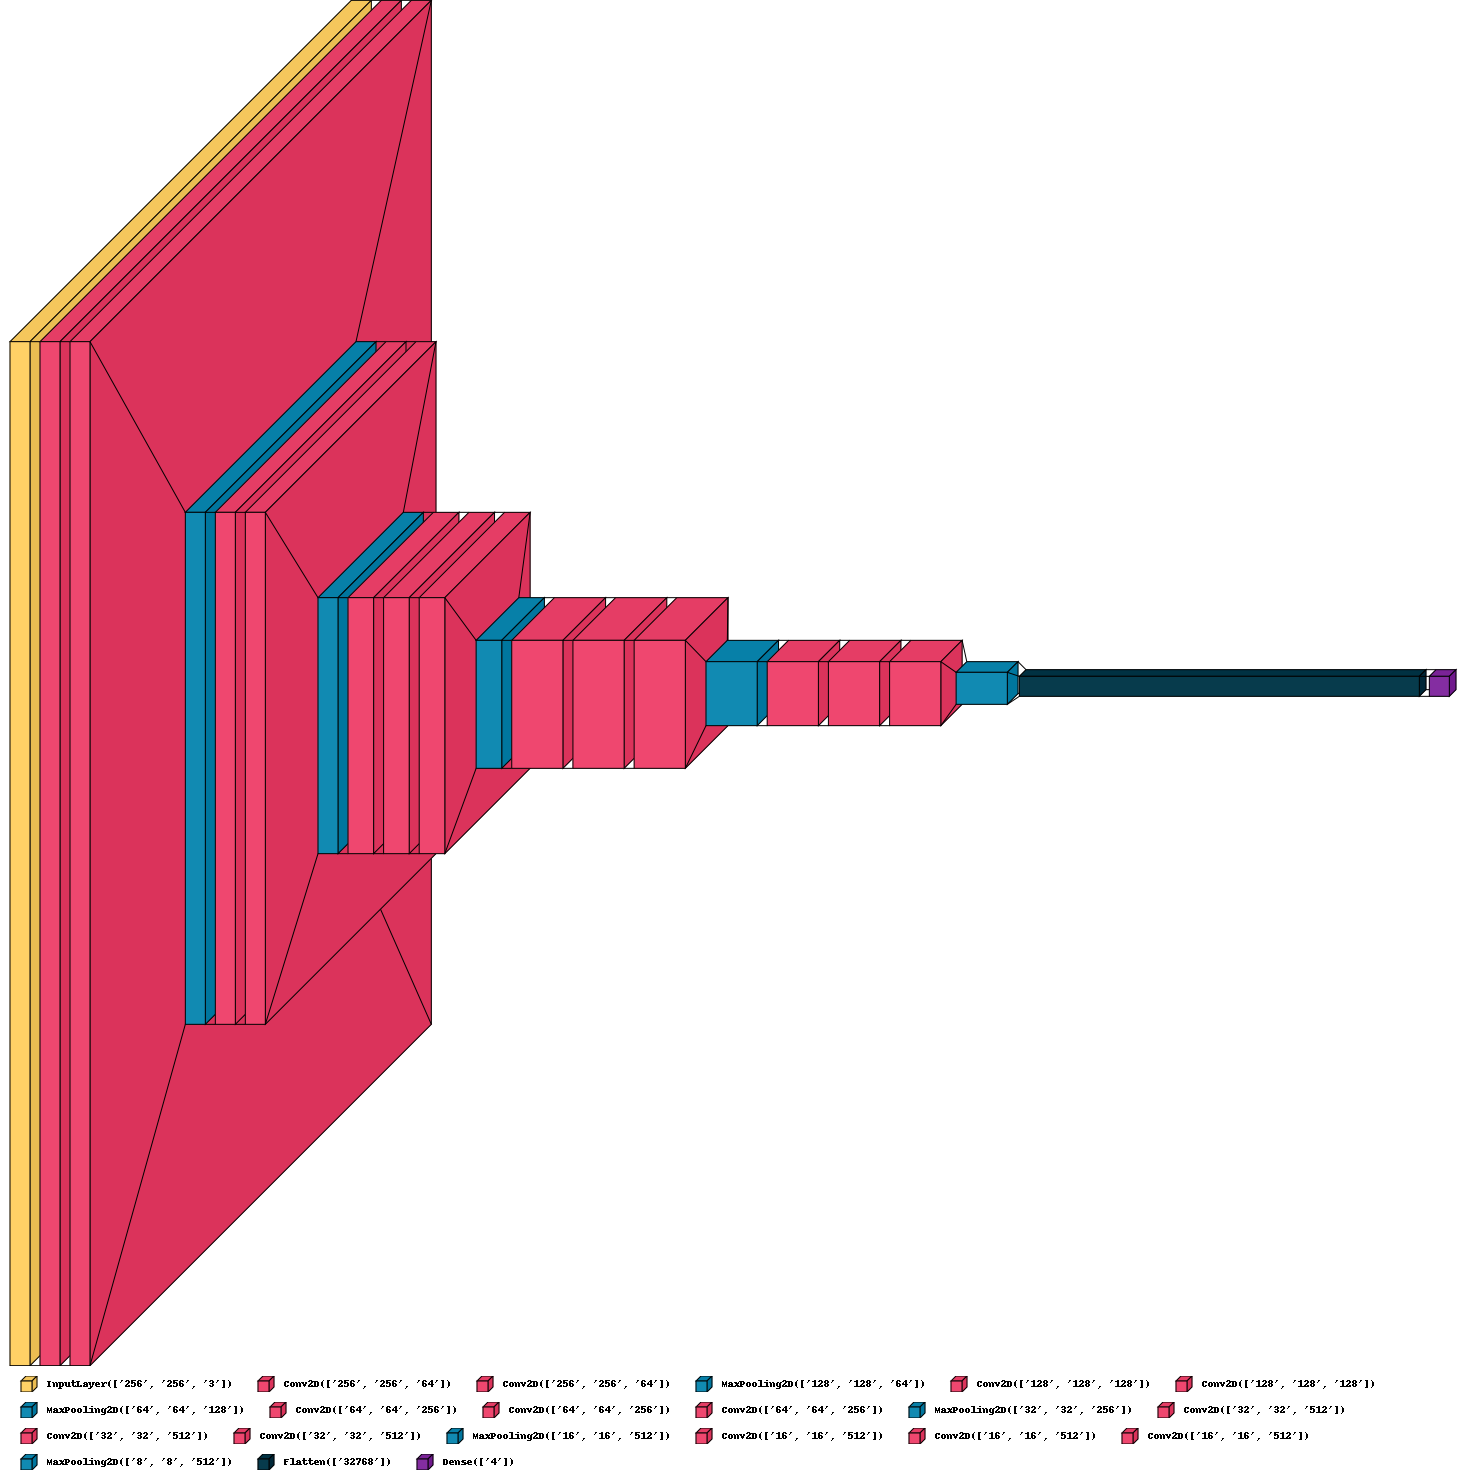

In [14]:
visualkeras.layered_view(vgg_model, legend=True,show_dimension=True)

### COMPILE AND TRAIN MODEL

In [ ]:
# Compile the model with AdamW optimizer
#optimizer = Adam(learning_rate=0.0001, clipnorm=1.0)

vgg_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',  # Use crossentropy because we have only four classes
                    metrics=['accuracy'])

In [ ]:
# Add ReduceLRnPlateau callback to reduce the learning rate
vgg16_reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                    factor=0.5,
                                    patience=2,
                                    verbose=1)

# Add EarlyStopping
vgg16_early_stop = EarlyStopping(monitor='val_loss',
                                 patience=10,
                                 verbose=1)

# To save the best model
vgg16_checkpoint = ModelCheckpoint(filepath= 'NEW_VGG16_model.keras',verbose=1, save_best_only=True)




# train model on 100 epoch
vgg16_history = vgg_model.fit(train_set,
                                epochs=100,
                                validation_data=val_set,
                                class_weight=class_weight_dict,
                                callbacks=[vgg16_reduce_lr, vgg16_early_stop,vgg16_checkpoint])

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.7509 - loss: 0.6349
Epoch 1: val_loss improved from inf to 0.62292, saving model to NEW_VGG16_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.7508 - loss: 0.6352 - val_accuracy: 0.7682 - val_loss: 0.6229 - learning_rate: 0.0010
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.7761 - loss: 0.5772
Epoch 2: val_loss did not improve from 0.62292
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.7761 - loss: 0.5771 - val_accuracy: 0.6453 - val_loss: 1.0292 - learning_rate: 0.0010
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.7967 - loss: 0.5285
Epoch 3: val_loss improved from 0.62292 to 0.61958, saving model to NEW_VGG16_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7966 - loss: 0.5285 - val_accuracy: 0.7714 - val_loss: 0.6196 - learning_rate: 0.0010
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.8157 - loss: 0.4923 
Epoch 4: va

### PLOT TRAINING & VALIDATION ACCURACY AS WELL AS LOSS

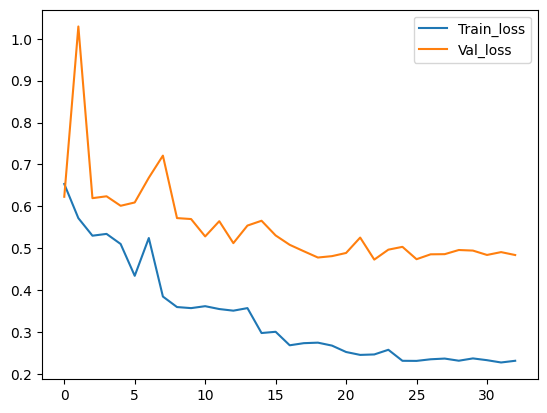

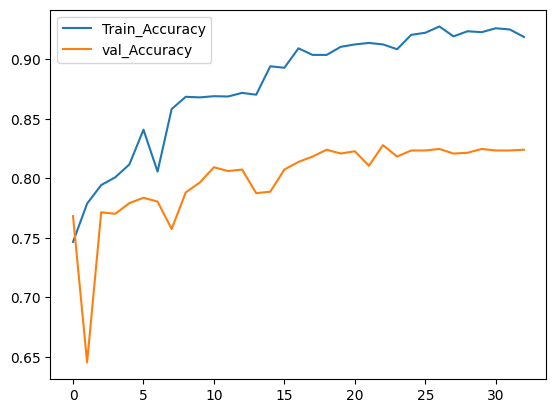

In [ ]:
# Training loss and validation loss
plt.plot(vgg16_history.history['loss'], label='Train_loss')
plt.plot(vgg16_history.history['val_loss'], label='Val_loss')
plt.legend()
plt.show()



# Training accuracy and validation accuracy
plt.plot(vgg16_history.history['accuracy'], label='Train_Accuracy')
plt.plot(vgg16_history.history['val_accuracy'], label='val_Accuracy')
plt.legend()
plt.show()


### MODEL EVALUATION

In [ ]:
train_result = vgg_model.evaluate(train_set)
print("VGG16 Train Accuracy & Loss:",train_result)

test_result = vgg_model.evaluate(test_set)
print("VGG16 Testing Accuracy & Loss",test_result)

63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9242 - loss: 0.2211
VGG16 Train Accuracy & Loss: [0.21958734095096588, 0.9248932600021362]
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step - accuracy: 0.8430 - loss: 0.5029
VGG16 Testing Accuracy & Loss [0.6840672492980957, 0.842024564743042]


* VGG16 model well perfrom on training data, but the model performance on testing data is slightly low.

### PREDICTION ON TEST DATA

In [ ]:
# Predict labels for the test set
vgg16_ypred = vgg_model.predict(X_test)

# Get class labels from predictions
y_pred_labels = np.argmax(vgg16_ypred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,f1_score,accuracy_score, recall_score

vgg16_confusion_matrix = confusion_matrix(y_test_labels, y_pred_labels)
print("Confusion Matrix:\n", vgg16_confusion_matrix)

Confusion Matrix:
 [[12  0  0  2]
 [ 1 22  0  3]
 [ 0  0 10  2]
 [ 0  0  0 12]]


In [ ]:
# F1 Score
VGG16_f1score = f1_score(y_test_labels, y_pred_labels,average='weighted')
print("F1 Score:", VGG16_f1score*100)

# Classification report
VGG16_report = classification_report(y_test_labels, y_pred_labels)
print("Classification Report:\n", VGG16_report)

F1 Score: 88.24561135549038
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89        14
           1       1.00      0.85      0.92        26
           2       1.00      0.83      0.91        12
           3       0.63      1.00      0.77        12

    accuracy                           0.88        64
   macro avg       0.89      0.88      0.87        64
weighted avg       0.91      0.88      0.88        64



##

## Xception MODEL

In [ ]:
from tensorflow.keras.applications import Xception

# Load Xception model with pre-trained weights
base_model = Xception(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Freeze the layers of the base model except the last 20
for layer in base_model.layers:
    layer.trainable = False

# Flatten the output layer to 1 dimension
x = Flatten()(base_model.output)

# Add a final Dense layer with softmax activation for classification
outputs = Dense(4, activation='softmax')(x)

# Create the final model
xception_model = Model(inputs=base_model.input, outputs=outputs)


83683744/83683744 [==============================] - 0s 0us/step


In [ ]:
# Summary of the model
xception_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 127, 127,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 127, 127,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 127, 127,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 125, 125,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 125, 125,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 125, 125,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 125, 125,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 125, 125,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 125, 125,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 125, 125,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 125, 125,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 63, 63,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 63, 63,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 63, 63,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 63, 63,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 63, 63,    │          0 │ add_12[0][0]    

 Total params: 21,385,772 (81.58 MB)

 Trainable params: 21,331,244 (81.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

### COMPILE AND TRAIN MODEL

In [ ]:
# Compile the model
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
# Use ReduceLROnPlateau to avoid overfitting
xception_lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1,min_lr=1e-6)

# Use earlyStopping to avoid overfitting
xception_early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# to save best model
Xception_checkpoint = ModelCheckpoint(filepath= 'NEW_XCEPTION_model.keras',verbose=1, save_best_only=True)

# train model on 100 epoch
xception_history = xception_model.fit(train_set,
                                      epochs=100,
                                      validation_data=val_set,
                                      class_weight=class_weight_dict,
                                      callbacks=[xception_lr_scheduler, xception_early_stopping,Xception_checkpoint])

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5921 - loss: 0.9795
Epoch 1: val_loss improved from inf to 0.92777, saving model to NEW_XCEPTION_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.5936 - loss: 0.9761 - val_accuracy: 0.6575 - val_loss: 0.9278 - learning_rate: 1.0000e-04
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8266 - loss: 0.4383
Epoch 2: val_loss improved from 0.92777 to 0.75268, saving model to NEW_XCEPTION_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.8267 - loss: 0.4384 - val_accuracy: 0.7362 - val_loss: 0.7527 - learning_rate: 1.0000e-04
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8770 - loss: 0.3285
Epoch 3: val_loss did not improve from 0.75268
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8771 - loss: 0.3282 - val_accuracy: 0.7330 - val_loss: 0.8352 - learning_rate: 1.0000e-04
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9273 - loss: 0.1966
Epoch

### PLOT TRAINING & VALIDATION ACCURACY AS WELL AS LOSS

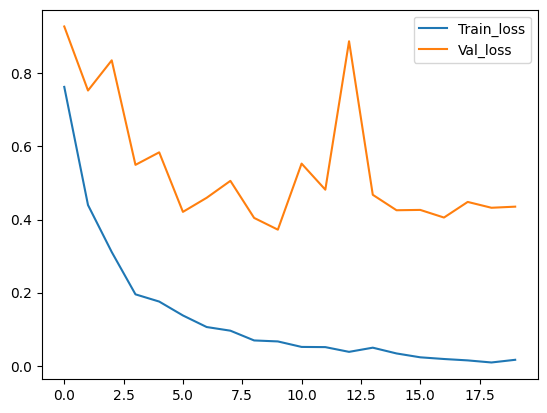

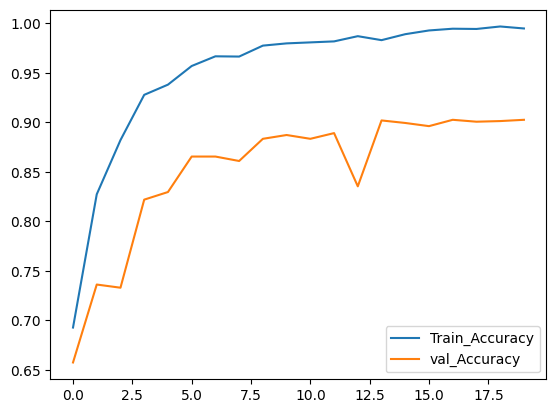

In [ ]:
# Training loss and validation loss
plt.plot(xception_history.history['loss'], label='Train_loss')
plt.plot(xception_history.history['val_loss'], label='Val_loss')
plt.legend()
plt.show()



# Training accuracy and validation accuracy
plt.plot(xception_history.history['accuracy'], label='Train_Accuracy')
plt.plot(xception_history.history['val_accuracy'], label='val_Accuracy')
plt.legend()
plt.show()


In [ ]:
train_result = xception_model.evaluate(train_set)
print("Xception Train Accuracy & Loss:",train_result)

test_result = xception_model.evaluate(test_set)
print("Xception Testing Accuracy & Loss",test_result)

63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9912 - loss: 0.0355
Xception Train Accuracy & Loss: [0.038487423211336136, 0.9879427552223206]
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9073 - loss: 0.3444 
Xception Testing Accuracy & Loss [0.35130202770233154, 0.9049080014228821]


* Xception model is also very well perform on training data as well as testing data accuracy is good.

### PREDICTION ON TEST DATA

In [ ]:
# Predict labels for the test set
xception_ypred = xception_model.predict(X_test)

# Get class labels from predictions
y_pred_labels = np.argmax(xception_ypred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,f1_score,accuracy_score, recall_score

xception_confusion_matrix = confusion_matrix(y_test_labels, y_pred_labels)
print("Confusion Matrix:\n", xception_confusion_matrix)

Confusion Matrix:
 [[11  0  1  0]
 [ 0 24  1  1]
 [ 0  1 10  0]
 [ 1  1  2 11]]


In [ ]:
# F1 Score
xception_f1score = f1_score(y_test_labels, y_pred_labels,average='weighted')
print("F1 Score:", xception_f1score*100)

# Classification report
xception_report = classification_report(y_test_labels, y_pred_labels)
print("Classification Report:\n", xception_report)

F1 Score: 87.53472222222221
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.92      0.92      0.92        26
           2       0.71      0.91      0.80        11
           3       0.92      0.73      0.81        15

    accuracy                           0.88        64
   macro avg       0.87      0.87      0.86        64
weighted avg       0.88      0.88      0.88        64



## InceptionV3 PRE-TRAINED MODEL

In [ ]:
from tensorflow.keras.applications import InceptionV3

input_shape = (256,256,3)

# Load the pre-trained InceptionV3 model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

# Here we are freeze the existing layers
for layer in base_model.layers:
    layer.trainable=False
    
# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 127, 127,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 127, 127,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 127, 127,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 125, 125,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 125, 125,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 62, 62,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 62, 62,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 62,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 62, 62,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 60, 60,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 60, 60,    │          0 │ batch_normalizat

 Total params: 23,905,060 (91.19 MB)

 Trainable params: 23,870,628 (91.06 MB)

 Non-trainable params: 34,432 (134.50 KB)

### COMPILE AND TRAIN MODEL

In [ ]:
# Compile model
#optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Use ReduceLROnPlateau to avoid overfitting
inception_lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1)

# Use earlyStopping to avoid overfitting
inception_early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# to save best model
inception_checkpoint = ModelCheckpoint(filepath= 'NEWINCEPTION_model.keras',verbose=1, save_best_only=True)

# train model on 100 epoch
inception_history = model.fit(train_set,
                              epochs=100,
                              validation_data=val_set,
                              class_weight=class_weight_dict,
                              callbacks=[inception_lr_scheduler, inception_early_stopping,inception_checkpoint])

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9678 - loss: 0.0991
Epoch 1: val_loss improved from inf to 0.38705, saving model to NEWINCEPTION_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9678 - loss: 0.0991 - val_accuracy: 0.8764 - val_loss: 0.3871 - learning_rate: 1.0000e-06
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9651 - loss: 0.1053
Epoch 2: val_loss did not improve from 0.38705
63/63 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9652 - loss: 0.1053 - val_accuracy: 0.8777 - val_loss: 0.4075 - learning_rate: 1.0000e-06
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9693 - loss: 0.0935
Epoch 3: val_loss did not improve from 0.38705
63/63 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9693 - loss: 0.0936 - val_accuracy: 0.8771 - val_loss: 0.4162 - learning_rate: 1.0000e-06
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9672 - loss: 0.1034
Epoch 4: val_loss did not improve from 0.38705
63/63

* Note:
Model is train in two phases, In first phase we train the model on 100 epoch and check the result then we seen the model training accuracy is more than testing, then we train the model on 100 epcohs to supress the overfitting of model.

### PLOT TRAINING & VALIDATION ACCURACY AS WELL AS LOSS


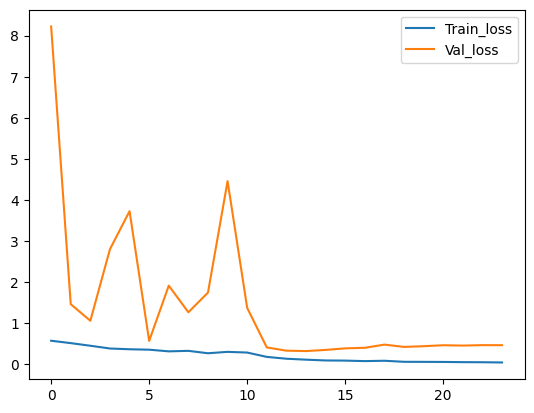

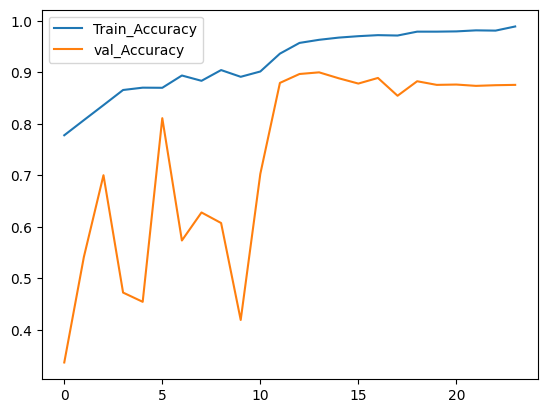

In [ ]:
# Training loss and validation loss
plt.plot(inception_history.history['loss'], label='Train_loss')
plt.plot(inception_history.history['val_loss'], label='Val_loss')
plt.legend()
plt.show()



# Training accuracy and validation accuracy
plt.plot(inception_history.history['accuracy'], label='Train_Accuracy')
plt.plot(inception_history.history['val_accuracy'], label='val_Accuracy')
plt.legend()
plt.show()


In [ ]:
train_result = model.evaluate(train_set)
print("InceptionV3 Train Accuracy & Loss:",train_result)

test_result = model.evaluate(test_set)
print("InceptionV3 Testing Accuracy & Loss",test_result)

63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9586 - loss: 0.1182
InceptionV3 Train Accuracy & Loss: [0.11828673630952835, 0.9570459723472595]
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9055 - loss: 0.3443 
InceptionV3 Testing Accuracy & Loss [0.330295592546463, 0.907975435256958]


* Inception model very well perform on training as well as testing data.


### PREDICTION ON TEST DATA

In [ ]:
# Predict labels for the test set
inception_ypred = model.predict(X_test)

# Get class labels from predictions
y_pred_labels = np.argmax(inception_ypred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,f1_score,accuracy_score, recall_score

inception_confusion_matrix = confusion_matrix(y_test_labels, y_pred_labels)
print("Confusion Matrix:\n", inception_confusion_matrix)

Confusion Matrix:
 [[10  0  0  2]
 [ 0 24  0  0]
 [ 1  0 14  0]
 [ 1  1  1 10]]


In [ ]:
# F1 Score
inception_f1score = f1_score(y_test_labels, y_pred_labels,average='weighted')
print("F1 Score:", inception_f1score*100)

# Classification report
inception_report = classification_report(y_test_labels, y_pred_labels)
print("Classification Report:\n", inception_report)

F1 Score: 90.48469387755101
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.96      1.00      0.98        24
           2       0.93      0.93      0.93        15
           3       0.83      0.77      0.80        13

    accuracy                           0.91        64
   macro avg       0.89      0.88      0.89        64
weighted avg       0.90      0.91      0.90        64



* InceptionV3 model F1 Score is also good.

## ANALYSIS OF ALL MODEL PERFORMANCE

In [5]:
import pandas as pd

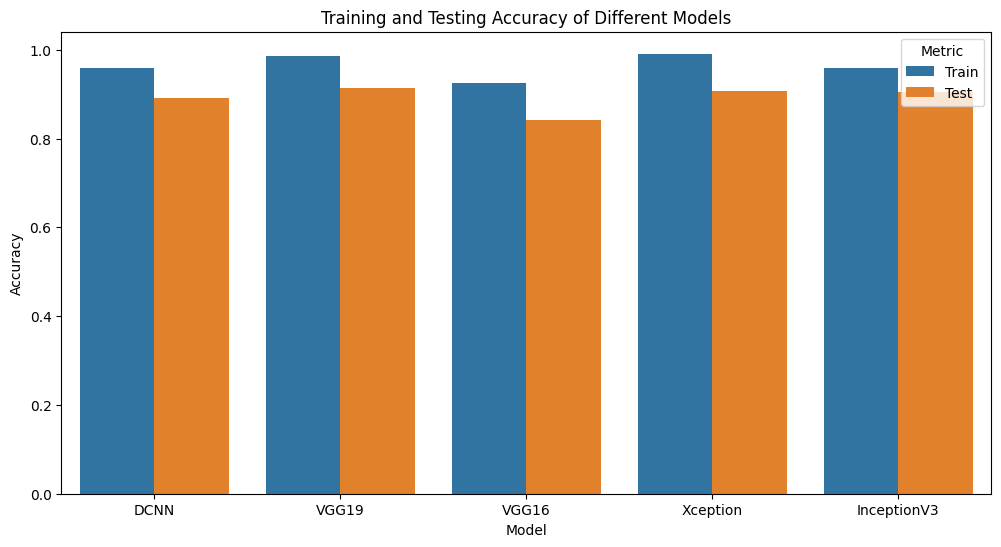

In [7]:
# Create all model train and test accuracy data frame
data = {
    'Model': ['DCNN', 'DCNN', 'VGG19', 'VGG19', 'VGG16', 'VGG16', 'Xception', 'Xception', 'InceptionV3', 'InceptionV3'],
    'Metric': ['Train', 'Test', 'Train', 'Test', 'Train', 'Test', 'Train', 'Test', 'Train', 'Test'],
    'Accuracy': [0.9586, 0.8916, 0.9850, 0.9129, 0.9242, 0.8430, 0.9912, 0.9073, 0.9586, 0.9055]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', hue='Metric', data=df)
plt.title('Training and Testing Accuracy of Different Models')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.show()


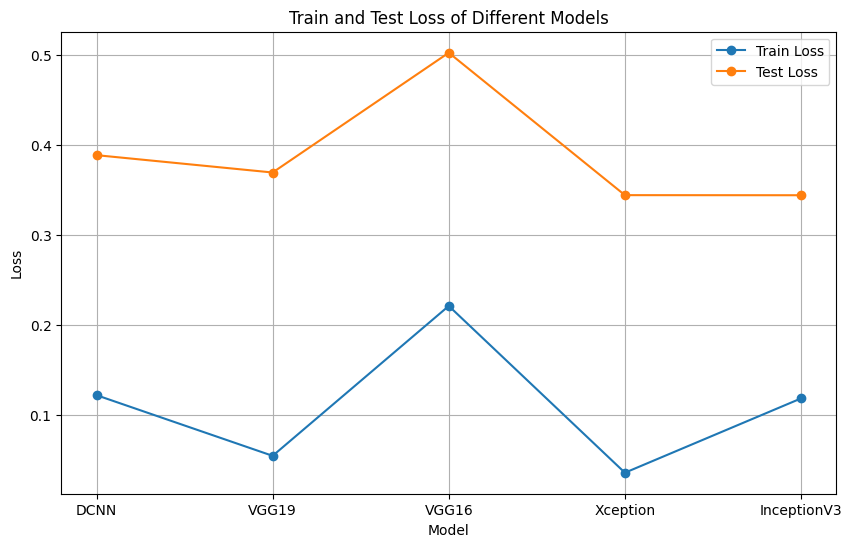

In [13]:
# plot train and test loss of different model
models = ['DCNN', 'VGG19', 'VGG16', 'Xception', 'InceptionV3']
train_losses = [0.1218, 0.0543, 0.2211, 0.0355, 0.1182]
test_losses = [0.3889, 0.3696, 0.5029, 0.3444, 0.3443]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(models, train_losses, marker='o', label='Train Loss')
plt.plot(models, test_losses, marker='o', label='Test Loss')

# Adding titles and labels
plt.title('Train and Test Loss of Different Models')
plt.xlabel('Model')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


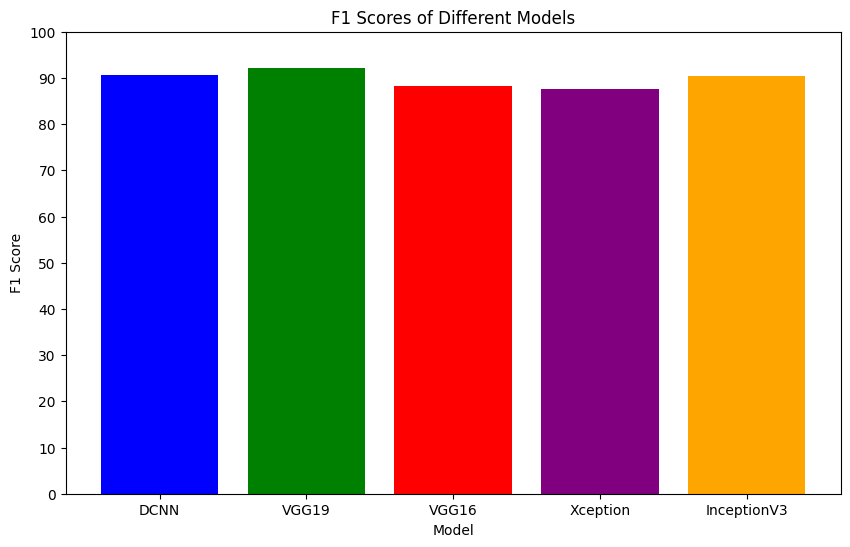

In [15]:
# F1 scores of each model
models = ['DCNN', 'VGG19', 'VGG16', 'Xception', 'InceptionV3']
f1_scores = [90.74, 92.10, 88.24, 87.53, 90.48]

# Plotting the bar plot
plt.figure(figsize=(10, 6))
plt.bar(models, f1_scores, color=['blue', 'green', 'red', 'purple', 'orange'])

# Adding titles and labels
plt.title('F1 Scores of Different Models')
plt.xlabel('Model')
plt.ylabel('F1 Score')
#plt.ylim(0, 100)
plt.yticks(range(0,110,10))
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


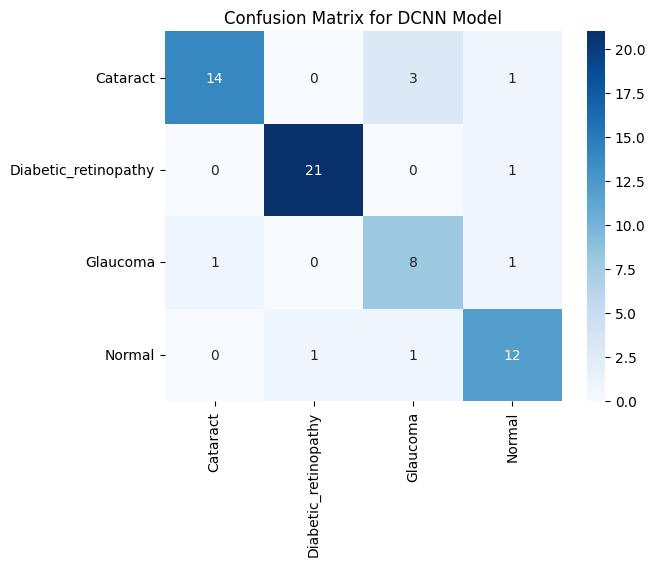

In [8]:
# Load the models
model_D = tf.keras.models.load_model("D.keras")
model_VGG19 = tf.keras.models.load_model("NEW_VGG19_model.keras")
model_VGG16 = tf.keras.models.load_model("NEW_VGG16_model.keras")
model_Inception = tf.keras.models.load_model("NEW_INCEPTION_model.keras")
model_Xception = tf.keras.models.load_model("NEW_XCEPTION_model.keras")

# Define class indices
class_indices = {'Cataract': 0, 'Diabetic_retinopathy': 1, 'Glaucoma': 2, 'Normal': 3}
class_labels = list(class_indices.keys())

y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to indices

# Resize X_test for DCNN model (224x224)
X_test_224 = tf.image.resize(X_test, (224, 224))

# Resize X_test for other models (256x256)
X_test_256 = tf.image.resize(X_test, (256, 256))

# Predict using DCNN model (224x224 input)
y_pred_D = np.argmax(model_D.predict(X_test_224), axis=1)
cm_D = confusion_matrix(y_true, y_pred_D, labels=list(class_indices.values()))
sns.heatmap(cm_D, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix for DCNN Model")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 8s/step


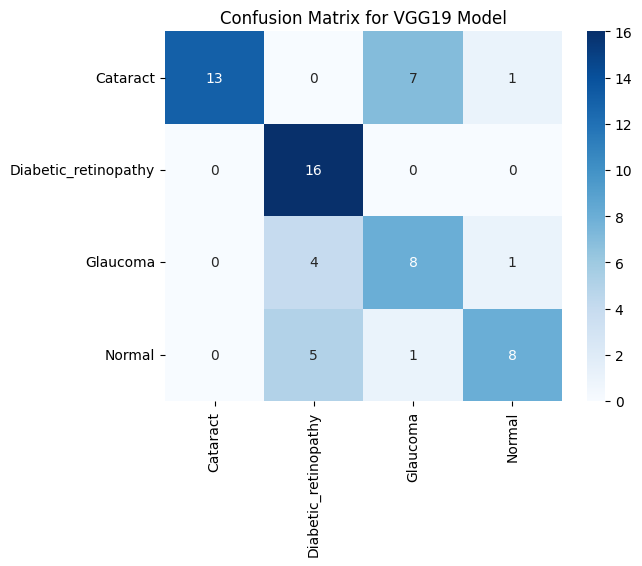

In [42]:
# Predict using model VGG19 (256x256 input)
y_pred_VGG19 = np.argmax(model_VGG19.predict(X_test_256), axis=1)
cm_VGG19 = confusion_matrix(y_true, y_pred_VGG19, labels=list(class_indices.values()))
sns.heatmap(cm_VGG19, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix for VGG19 Model")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 7s/step


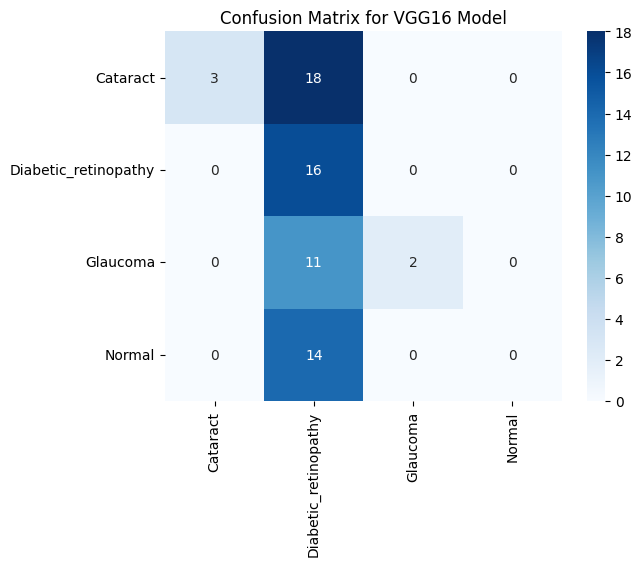

In [44]:
# Predict using model VGG16 (256x256 input)
y_pred_VGG16 = np.argmax(model_VGG16.predict(X_test_256), axis=1)
cm_VGG16 = confusion_matrix(y_true, y_pred_VGG16, labels=list(class_indices.values()))
sns.heatmap(cm_VGG16, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix for VGG16 Model")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step


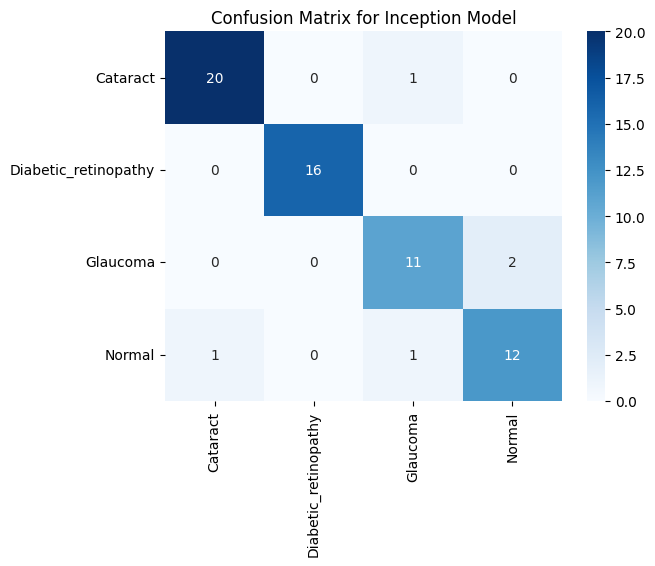

In [46]:
# Predict using model Inception (256x256 input)
y_pred_Inception = np.argmax(model_Inception.predict(X_test_256), axis=1)
cm_Inception = confusion_matrix(y_true, y_pred_Inception, labels=list(class_indices.values()))
sns.heatmap(cm_Inception, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix for Inception Model")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 106s 53s/step


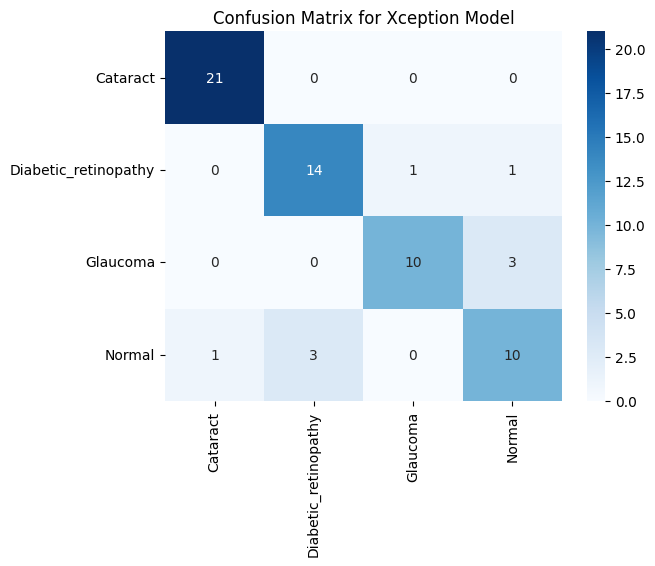

In [48]:
# Predict using model Xception (256x256 input)
y_pred_Xception = np.argmax(model_Xception.predict(X_test_256), axis=1)
cm_Xception = confusion_matrix(y_true, y_pred_Xception, labels=list(class_indices.values()))
sns.heatmap(cm_Xception, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix for Xception Model")
plt.show()

## Conclusion:
* Base on the above all model DCNN, VGG19 and InceptionV3 model perform very well on training as well as testing data.
* Xception model also very well perform of training data. but the testing accuracy is less, means the model is overfit, as well as F1 score is less than 90%.
* VGG16 Model perform well on training data but testing and F1 Score is less.
* Based on above all model I choose the InceptionV3 and DCNN Model because of training and testing accuracy is very well, also F1 Score is 90%.

##  LOAD MODEL AND TEST IMAGES WITH GRADIO SPACES

In [2]:
# Load your model
model = load_model("NEW_INCEPTION_model.keras")

# Define the class names
class_names = ['Cataract','Diabetic Retinopathy','Glaucoma','Normal']

# Create CLAHE function to enhance the quality of the image
def apply_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final

# Preprocess image
def preprocess_image(image):
    image = cv2.resize(image, (256,256))  # Resize to model input size
    image = apply_clahe(image)
    image = img_to_array(image)
    image = image / 255.0  # Normalize to [0, 1]
    image = np.expand_dims(image, axis=0)
    return image

# Make prediction with batch processing
def predict_fn(images):
    images = np.array(images).astype(np.float32) / 255.0
    return model.predict(images)

# Define function to get LIME explanation
def generate_lime_explanation(image):
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        image, 
        predict_fn, 
        top_labels=1, 
        hide_color=0, 
        num_samples=200  # Reduced for faster performance
    )
    
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], 
        positive_only=True, 
        num_features=10,  # Reduced number of features
        hide_rest=False
    )
    
    # Generate heatmap
    top_label = explanation.top_labels[0]
    local_explanation = dict(explanation.local_exp[top_label])
    heatmap = np.zeros(mask.shape[:2])
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j] in local_explanation:
                heatmap[i, j] = local_explanation[mask[i, j]]
    heatmap /= np.max(heatmap)
    
    # Plot heatmap
    fig, ax = plt.subplots()
    sns.heatmap(heatmap, cmap='viridis', alpha=0.6, ax=ax, zorder=2, cbar=True)
    ax.imshow(image / 255.0, zorder=1, alpha=0.4)
    ax.axis('off')
    plt.close(fig)
    
    return fig

# Main prediction function
def predict(image):
    try:
        image_np = np.array(image)
        processed_image = preprocess_image(image_np)
        prediction = model.predict(processed_image)
        class_idx = tf.argmax(prediction, axis=1).numpy()[0]
        confidence = tf.reduce_max(prediction).numpy()
        
        lime_explanation = generate_lime_explanation(image_np)
        
        return apply_clahe(image_np), lime_explanation, class_names[class_idx], f"{confidence:.2f}"
    except Exception as e:
        print(f"Error: {e}")
        raise e


In [3]:
# Create the Gradio interface
iface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type='pil', label='Upload an Image'),
    outputs=[
        # gr.Image(type='numpy', label='Original Image'),
        gr.Image(type='numpy', label='CLAHE Processed Image'),
        gr.Plot(label='LIME Explanation'),
        gr.Label(label='Predicted Class'),
        gr.Textbox(label='Confidence')
    ],
    title='Ocular Disease Classification with LIME Explanation',
    description='Upload an ocular image to classify it as Normal, Glaucoma, Diabetic Retinopathy, or Cataract. The image will be preprocessed with CLAHE before prediction, and a LIME explanation will be provided.'
)

iface.launch(share=True)

Running on local URL:  http://127.0.0.1:7860
Running on public URL: https://19a5133393fb63b483.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
